# Telecom churn prediction

In [1]:
# Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Data Loading

In [2]:
dataset = pd.read_csv("/content/telecom_customer_churn.csv")


# Basic Data Inspection

1. Display top rows
2. Display Bottom rows
3. Display Data Types
4. Summary Statistics
5. Display Index, Columns, and Data

In [3]:
dataset.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [4]:
dataset.tail()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
7038,9987-LUTYD,Female,20,No,0,La Mesa,91941,32.759327,-116.997260,0,...,Credit Card,55.15,742.90,0.0,0,606.84,1349.74,Stayed,NaN,NaN
7039,9992-RRAMN,Male,40,Yes,0,Riverbank,95367,37.734971,-120.954271,1,...,Bank Withdrawal,85.10,1873.70,0.0,0,356.40,2230.10,Churned,Dissatisfaction,Product dissatisfaction
7040,9992-UJOEL,Male,22,No,0,Elk,95432,39.108252,-123.645121,0,...,Credit Card,50.30,92.75,0.0,0,37.24,129.99,Joined,NaN,NaN
7041,9993-LHIEB,Male,21,Yes,0,Solana Beach,92075,33.001813,-117.263628,5,...,Credit Card,67.85,4627.65,0.0,0,142.04,4769.69,Stayed,NaN,NaN
7042,9995-HOTOH,Male,36,Yes,0,Sierra City,96125,39.600599,-120.636358,1,...,Bank Withdrawal,59.00,3707.60,0.0,0,0.00,3707.60,Stayed,NaN,NaN


In [5]:
dataset.shape

(7043, 38)

In [6]:
dataset.dtypes

,0
Customer ID,object
Gender,object
Age,int64
Married,object
Number of Dependents,int64
City,object
Zip Code,int64
Latitude,float64
Longitude,float64
Number of Referrals,int64


In [7]:
# statical measurement
dataset.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,6361.000000,5517.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,25.420517,26.189958,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,14.200374,19.586585,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,1.010000,2.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,13.050000,13.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,25.690000,21.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,37.680000,30.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   objec

# Data Cleaning

1. Check for Missing Values
2. Fill Missing Values
3. Drop Missing Values
4. Rename Columns
5. Drop Columns

In [9]:
dataset.isnull().sum()

,0
Customer ID,0
Gender,0
Age,0
Married,0
Number of Dependents,0
City,0
Zip Code,0
Latitude,0
Longitude,0
Number of Referrals,0


In [10]:

dataset.duplicated().sum()

np.int64(0)

In [11]:


dataset.columns

Index(['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents',
       'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason'],
      dtype='object')

In [12]:
dataset.drop(columns=['Churn Category','Churn Reason','Customer ID','City','Zip Code','Latitude','Longitude','Streaming Movies','Streaming Music'], inplace=True)

In [13]:
dataset.head()

,Gender,Age,Married,Number of Dependents,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,...,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status
0,Female,37,Yes,0,2,9,NaN,Yes,42.39,No,...,One Year,Yes,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed
1,Male,46,No,0,0,9,NaN,Yes,10.69,Yes,...,Month-to-Month,No,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed
2,Male,50,No,0,0,4,Offer E,Yes,33.65,No,...,Month-to-Month,Yes,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned
3,Male,78,Yes,0,1,13,Offer D,Yes,27.82,No,...,Month-to-Month,Yes,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned
4,Female,75,Yes,0,3,3,NaN,Yes,7.38,No,...,Month-to-Month,Yes,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned


# Handling Null values
1. using forwardfill method using mean

In [14]:
dataset['Offer'] = dataset['Offer'].fillna('No Offer')

In [15]:
dataset['Avg Monthly Long Distance Charges'] = dataset['Avg Monthly Long Distance Charges'].fillna(dataset['Avg Monthly Long Distance Charges'].mean())

In [16]:
# For 'Multiple Lines', if 'Phone Service' is 'No', then 'Multiple Lines' is 'No'. Otherwise, if it's still null, fill with 'No'.
dataset.loc[dataset['Phone Service'] == 'No', 'Multiple Lines'] = 'No'
dataset['Multiple Lines'] = dataset['Multiple Lines'].fillna('No')

In [17]:
# For Internet Service related columns
internet_related_cols_cat = ['Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Unlimited Data']
internet_related_col_num = 'Avg Monthly GB Download'

# If 'Internet Service' is 'No', fill related columns with 'No Internet' or 0
dataset.loc[dataset['Internet Service'] == 'No', internet_related_cols_cat] = 'No Internet'
dataset.loc[dataset['Internet Service'] == 'No', internet_related_col_num] = 0

# For remaining nulls (where Internet Service is 'Yes' but sub-services are null), fill categorical with 'No' and numerical with 0
for col in internet_related_cols_cat:
    dataset[col] = dataset[col].fillna('No')
dataset[internet_related_col_num] = dataset[internet_related_col_num].fillna(0)

In [18]:
# After handling null values

dataset.isnull().sum()

,0
Gender,0
Age,0
Married,0
Number of Dependents,0
Number of Referrals,0
Tenure in Months,0
Offer,0
Phone Service,0
Avg Monthly Long Distance Charges,0
Multiple Lines,0


In [19]:
dataset.shape

(7043, 29)

In [20]:
dataset.head()

,Gender,Age,Married,Number of Dependents,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,...,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status
0,Female,37,Yes,0,2,9,No Offer,Yes,42.39,No,...,One Year,Yes,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed
1,Male,46,No,0,0,9,No Offer,Yes,10.69,Yes,...,Month-to-Month,No,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed
2,Male,50,No,0,0,4,Offer E,Yes,33.65,No,...,Month-to-Month,Yes,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned
3,Male,78,Yes,0,1,13,Offer D,Yes,27.82,No,...,Month-to-Month,Yes,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned
4,Female,75,Yes,0,3,3,No Offer,Yes,7.38,No,...,Month-to-Month,Yes,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned


In [21]:
dataset.columns

Index(['Gender', 'Age', 'Married', 'Number of Dependents',
       'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Unlimited Data', 'Contract',
       'Paperless Billing', 'Payment Method', 'Monthly Charge',
       'Total Charges', 'Total Refunds', 'Total Extra Data Charges',
       'Total Long Distance Charges', 'Total Revenue', 'Customer Status'],
      dtype='object')

# Data Visulization Integration

1. Histogram
2. Boxplot
3. Count Plot
4. Bar Chart

# To Find categorical column

In [22]:
# Find categorical column
categorical_col = dataset.select_dtypes(include='object')
categorical_col.head()

#

,Gender,Married,Offer,Phone Service,Multiple Lines,Internet Service,Internet Type,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Unlimited Data,Contract,Paperless Billing,Payment Method,Customer Status
0,Female,Yes,No Offer,Yes,No,Yes,Cable,No,Yes,No,Yes,Yes,Yes,One Year,Yes,Credit Card,Stayed
1,Male,No,No Offer,Yes,Yes,Yes,Cable,No,No,No,No,No,No,Month-to-Month,No,Credit Card,Stayed
2,Male,No,Offer E,Yes,No,Yes,Fiber Optic,No,No,Yes,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,Churned
3,Male,Yes,Offer D,Yes,No,Yes,Fiber Optic,No,Yes,Yes,No,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,Churned
4,Female,Yes,No Offer,Yes,No,Yes,Fiber Optic,No,No,No,Yes,Yes,Yes,Month-to-Month,Yes,Credit Card,Churned


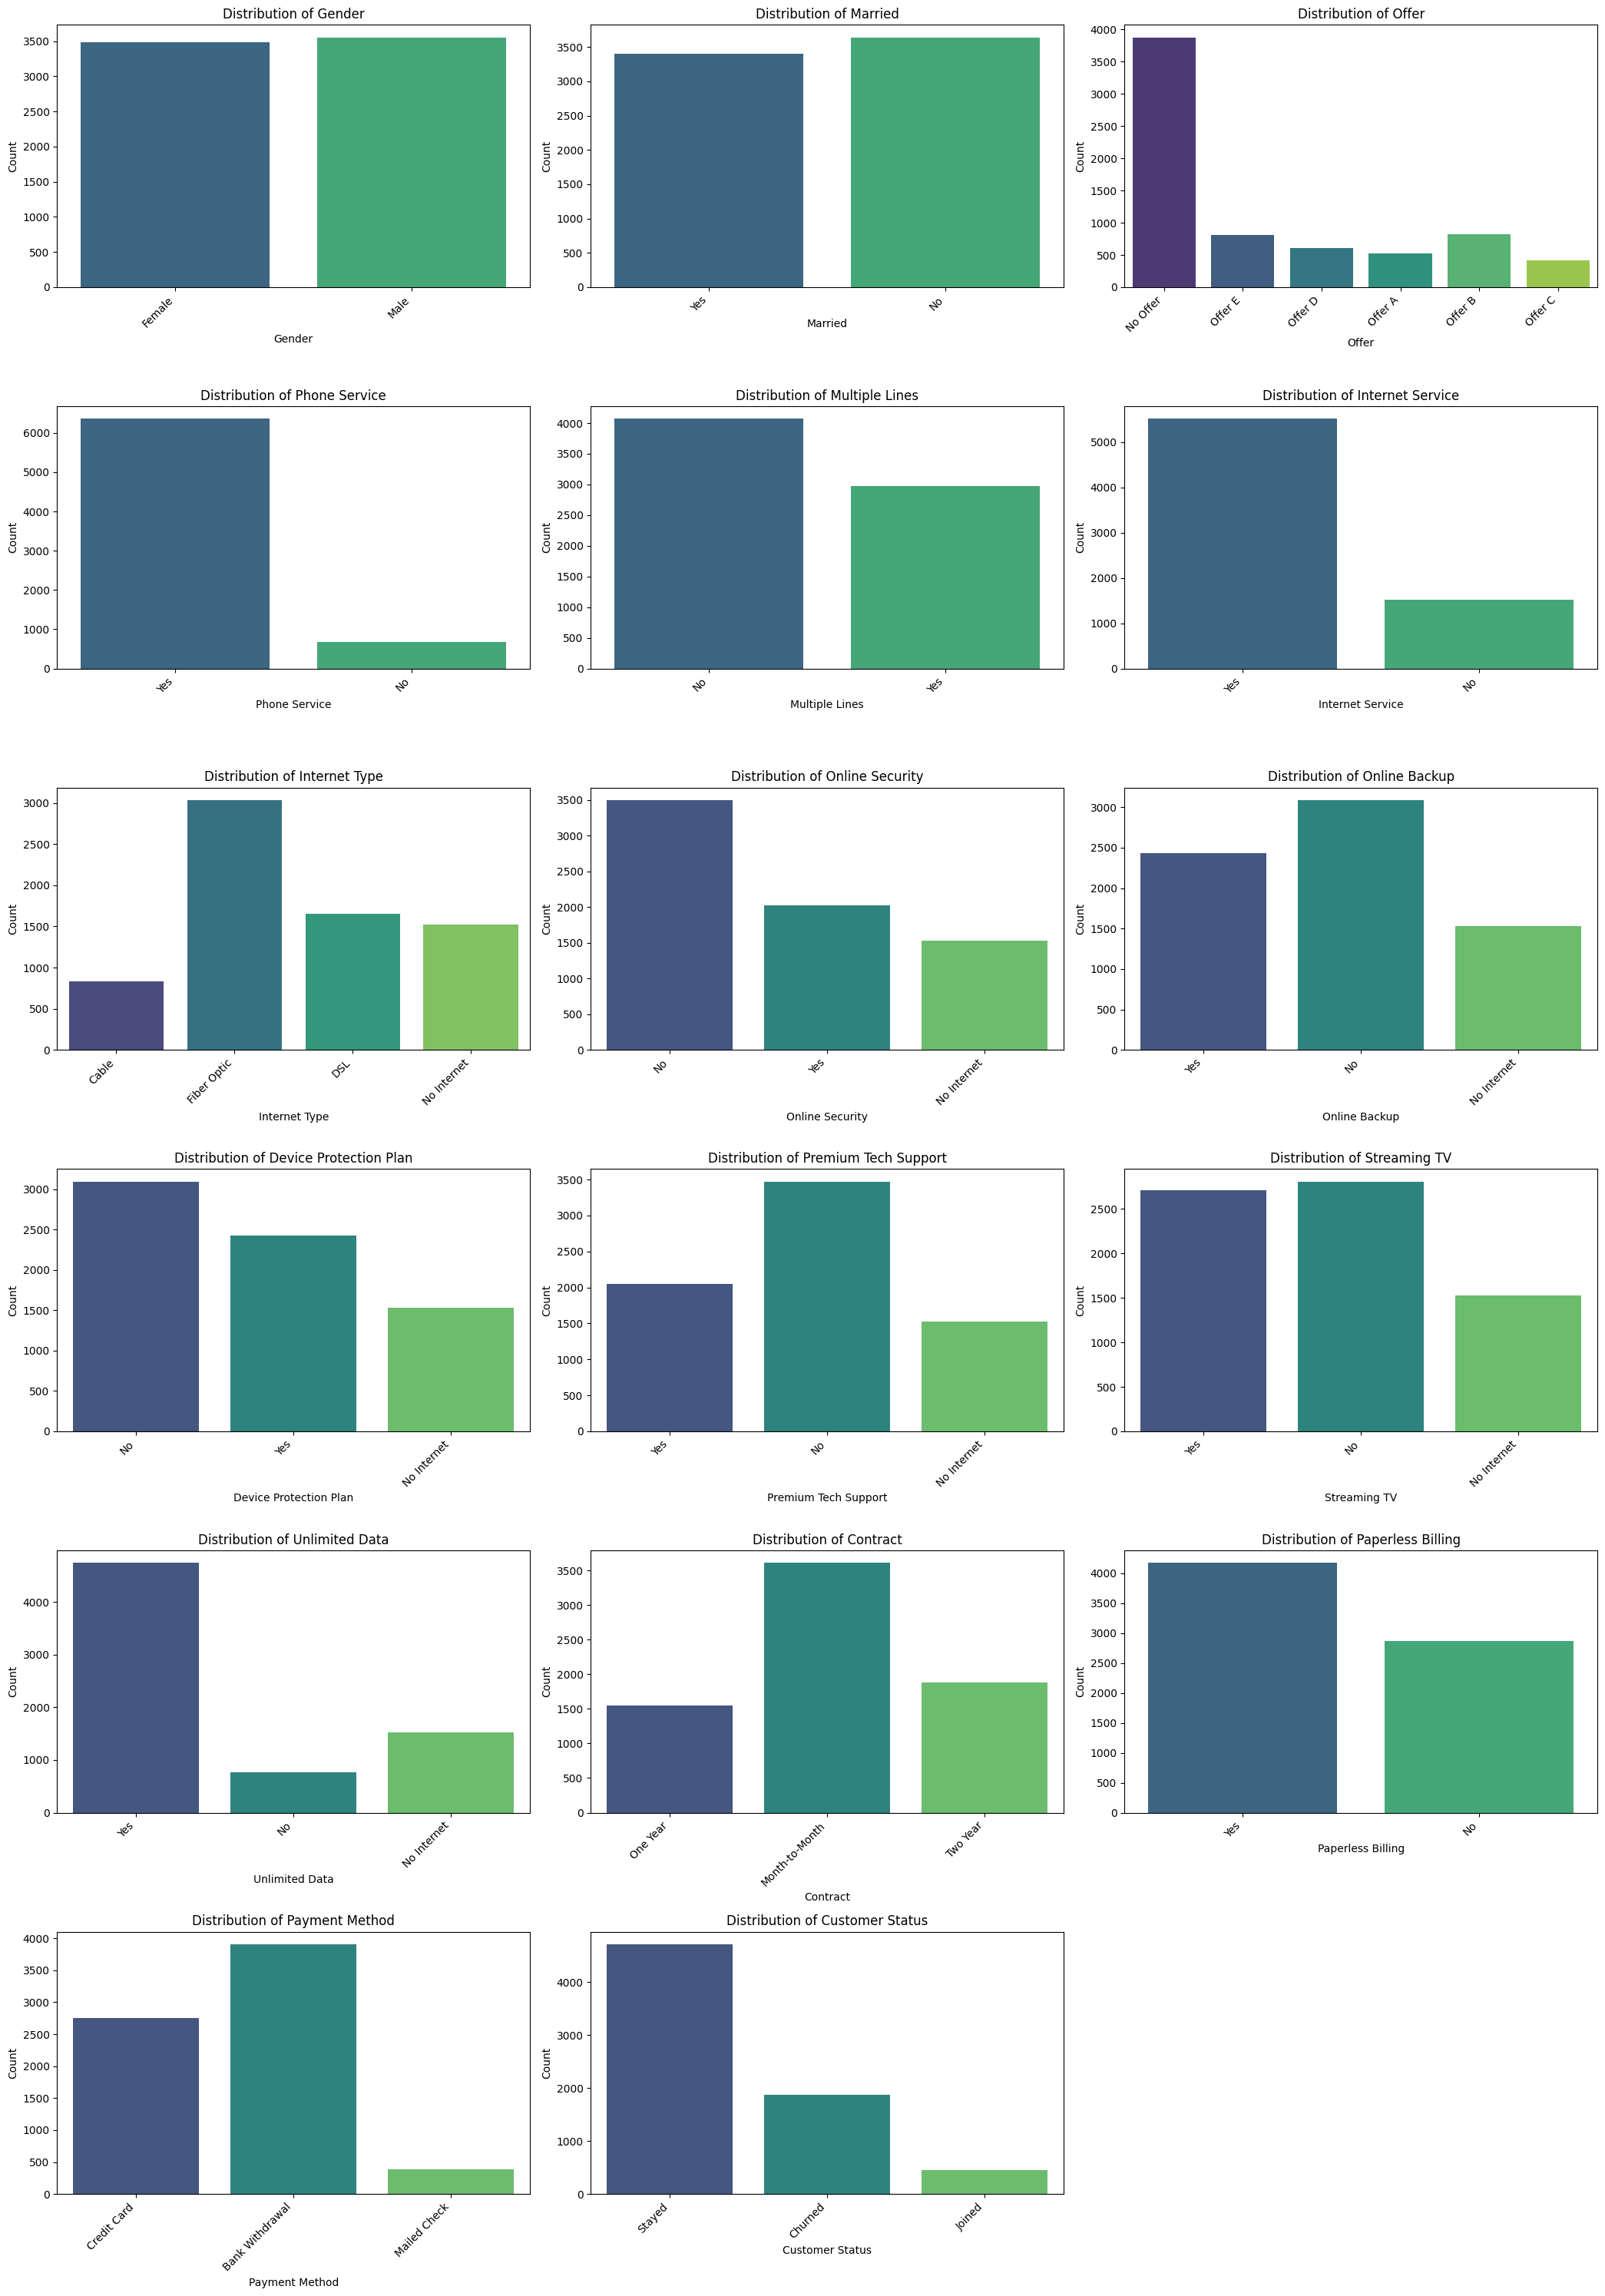

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

categorical_cols = dataset.select_dtypes(include='object').columns.tolist()

# Calculate grid dimensions for subplots
num_features = len(categorical_cols)
num_cols_plot = 3 # Aim for 3 columns per row for better readability
num_rows_plot = math.ceil(num_features / num_cols_plot)

plt.figure(figsize=(num_cols_plot * 7, num_rows_plot * 5))

for i, column in enumerate(categorical_cols):
    plt.subplot(num_rows_plot, num_cols_plot, i + 1)
    sns.countplot(data=dataset, x=column, palette='viridis', hue=column, legend=False)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# To apply chi-Square test for feature selection

if the p-value of categorical column is less significance level (alpha = 0.05) then the feature is Statistically significance relationship with Customer Status(target value)

In [24]:
from scipy.stats import chi2_contingency
import pandas as pd

chi2_results = {}
alph = 0.05

# Assuming 'categorical_features_for_analysis' is already defined
# and contains all relevant categorical features except 'Customer Status' itself.
# We will directly use 'Customer Status' as the target variable here.

# Re-define categorical_features_for_analysis excluding 'Customer Status'
categorical_features_for_analysis = dataset.select_dtypes(include='object').columns.tolist()
if 'Customer Status' in categorical_features_for_analysis:
    categorical_features_for_analysis.remove('Customer Status')

for feature in categorical_features_for_analysis:
    contingency_table = pd.crosstab(dataset[feature], dataset['Customer Status'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    chi2_results[feature] = p_value

    print(f"Feature: {feature}")
    print(f"  P-value: {p_value:.4f}")
    if p_value < alph:
        print(f"  Conclusion: Statistically significant relationship with Customer Status (p < {alph})")
    else:
        print(f"  Conclusion: No statistically significant relationship with Customer Status (p >= {alph})")
    print("\n" + "-"*50 + "\n")

Feature: Gender
  P-value: 0.3549
  Conclusion: No statistically significant relationship with Customer Status (p >= 0.05)

--------------------------------------------------

Feature: Married
  P-value: 0.0000
  Conclusion: Statistically significant relationship with Customer Status (p < 0.05)

--------------------------------------------------

Feature: Offer
  P-value: 0.0000
  Conclusion: Statistically significant relationship with Customer Status (p < 0.05)

--------------------------------------------------

Feature: Phone Service
  P-value: 0.3121
  Conclusion: No statistically significant relationship with Customer Status (p >= 0.05)

--------------------------------------------------

Feature: Multiple Lines
  P-value: 0.0000
  Conclusion: Statistically significant relationship with Customer Status (p < 0.05)

--------------------------------------------------

Feature: Internet Service
  P-value: 0.0000
  Conclusion: Statistically significant relationship with Customer Status

In [25]:
dataset = dataset.drop(columns = ['Gender','Phone Service'])

In [26]:
dataset.head()

,Age,Married,Number of Dependents,Number of Referrals,Tenure in Months,Offer,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,...,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status
0,37,Yes,0,2,9,No Offer,42.39,No,Yes,Cable,...,One Year,Yes,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed
1,46,No,0,0,9,No Offer,10.69,Yes,Yes,Cable,...,Month-to-Month,No,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed
2,50,No,0,0,4,Offer E,33.65,No,Yes,Fiber Optic,...,Month-to-Month,Yes,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned
3,78,Yes,0,1,13,Offer D,27.82,No,Yes,Fiber Optic,...,Month-to-Month,Yes,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned
4,75,Yes,0,3,3,No Offer,7.38,No,Yes,Fiber Optic,...,Month-to-Month,Yes,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned


# To find Numerical columns to detect outliers

In [27]:
numerical_cols = dataset.select_dtypes(include='number')
numerical_cols.head()

,Age,Number of Dependents,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
0,37,0,2,9,42.39,16.0,65.6,593.30,0.00,0,381.51,974.81
1,46,0,0,9,10.69,10.0,-4.0,542.40,38.33,10,96.21,610.28
2,50,0,0,4,33.65,30.0,73.9,280.85,0.00,0,134.60,415.45
3,78,0,1,13,27.82,4.0,98.0,1237.85,0.00,0,361.66,1599.51
4,75,0,3,3,7.38,11.0,83.9,267.40,0.00,0,22.14,289.54


# To apply Annova test in numerical col

In [28]:
from scipy.stats import f_oneway

numerical_features = numerical_cols.columns.tolist()

print("Performing ANOVA test for each numerical feature against 'Customer Status':\n")

alph = 0.05 # Significance level

for feature in numerical_features:
    # Extract data for each customer status group
    group_stayed = dataset[dataset['Customer Status'] == 'Stayed'][feature]
    group_churned = dataset[dataset['Customer Status'] == 'Churned'][feature]
    group_joined = dataset[dataset['Customer Status'] == 'Joined'][feature]

    # Perform one-way ANOVA test
    # Handle cases where a group might be empty, though unlikely with this dataset
    # f_oneway expects at least two non-empty arrays
    valid_groups = [g for g in [group_stayed, group_churned, group_joined] if not g.empty]

    if len(valid_groups) < 2:
        print(f"Feature: {feature}")
        print(f"  Not enough valid groups to perform ANOVA.\n" + "-"*50 + "\n")
        continue

    f_statistic, p_value = f_oneway(*valid_groups)

    print(f"Feature: {feature}")
    print(f"  F-statistic: {f_statistic:.4f}")
    print(f"  P-value: {p_value:.4f}")

    if p_value < alph:
        print(f"  Conclusion: Statistically significant difference in means across Customer Status groups (p < {alph})")
    else:
        print(f"  Conclusion: No statistically significant difference in means across Customer Status groups (p >= {alph})")
    print("\n" + "-"*50 + "\n")

Performing ANOVA test for each numerical feature against 'Customer Status':

Feature: Age
  F-statistic: 53.3953
  P-value: 0.0000
  Conclusion: Statistically significant difference in means across Customer Status groups (p < 0.05)

--------------------------------------------------

Feature: Number of Dependents
  F-statistic: 193.2410
  P-value: 0.0000
  Conclusion: Statistically significant difference in means across Customer Status groups (p < 0.05)

--------------------------------------------------

Feature: Number of Referrals
  F-statistic: 392.0570
  P-value: 0.0000
  Conclusion: Statistically significant difference in means across Customer Status groups (p < 0.05)

--------------------------------------------------

Feature: Tenure in Months
  F-statistic: 1338.4368
  P-value: 0.0000
  Conclusion: Statistically significant difference in means across Customer Status groups (p < 0.05)

--------------------------------------------------

Feature: Avg Monthly Long Distance Charge

The ANOVA test results above indicate, for each numerical feature, whether there's a statistically significant difference in its mean value when grouped by 'Customer Status' (Stayed, Churned, Joined). A low p-value (typically < 0.05) suggests that the means are not all equal, implying that the numerical feature likely plays a role in differentiating between these customer status groups.

In [29]:
dataset = dataset.drop(columns = ['Avg Monthly Long Distance Charges'])

# Data visulization part

/tmp/ipython-input-194/3636859564.py:16: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=dataset, x=column, kde=True, bins=50, palette='viridis', legend=False)
/tmp/ipython-input-194/3636859564.py:16: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=dataset, x=column, kde=True, bins=50, palette='viridis', legend=False)
/tmp/ipython-input-194/3636859564.py:16: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=dataset, x=column, kde=True, bins=50, palette='viridis', legend=False)
/tmp/ipython-input-194/3636859564.py:16: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=dataset, x=column, kde=True, bins=50, palette='viridis', legend=False)
/tmp/ipython-input-194/3636859564.py:16: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=dataset, x=column, kde=Tru

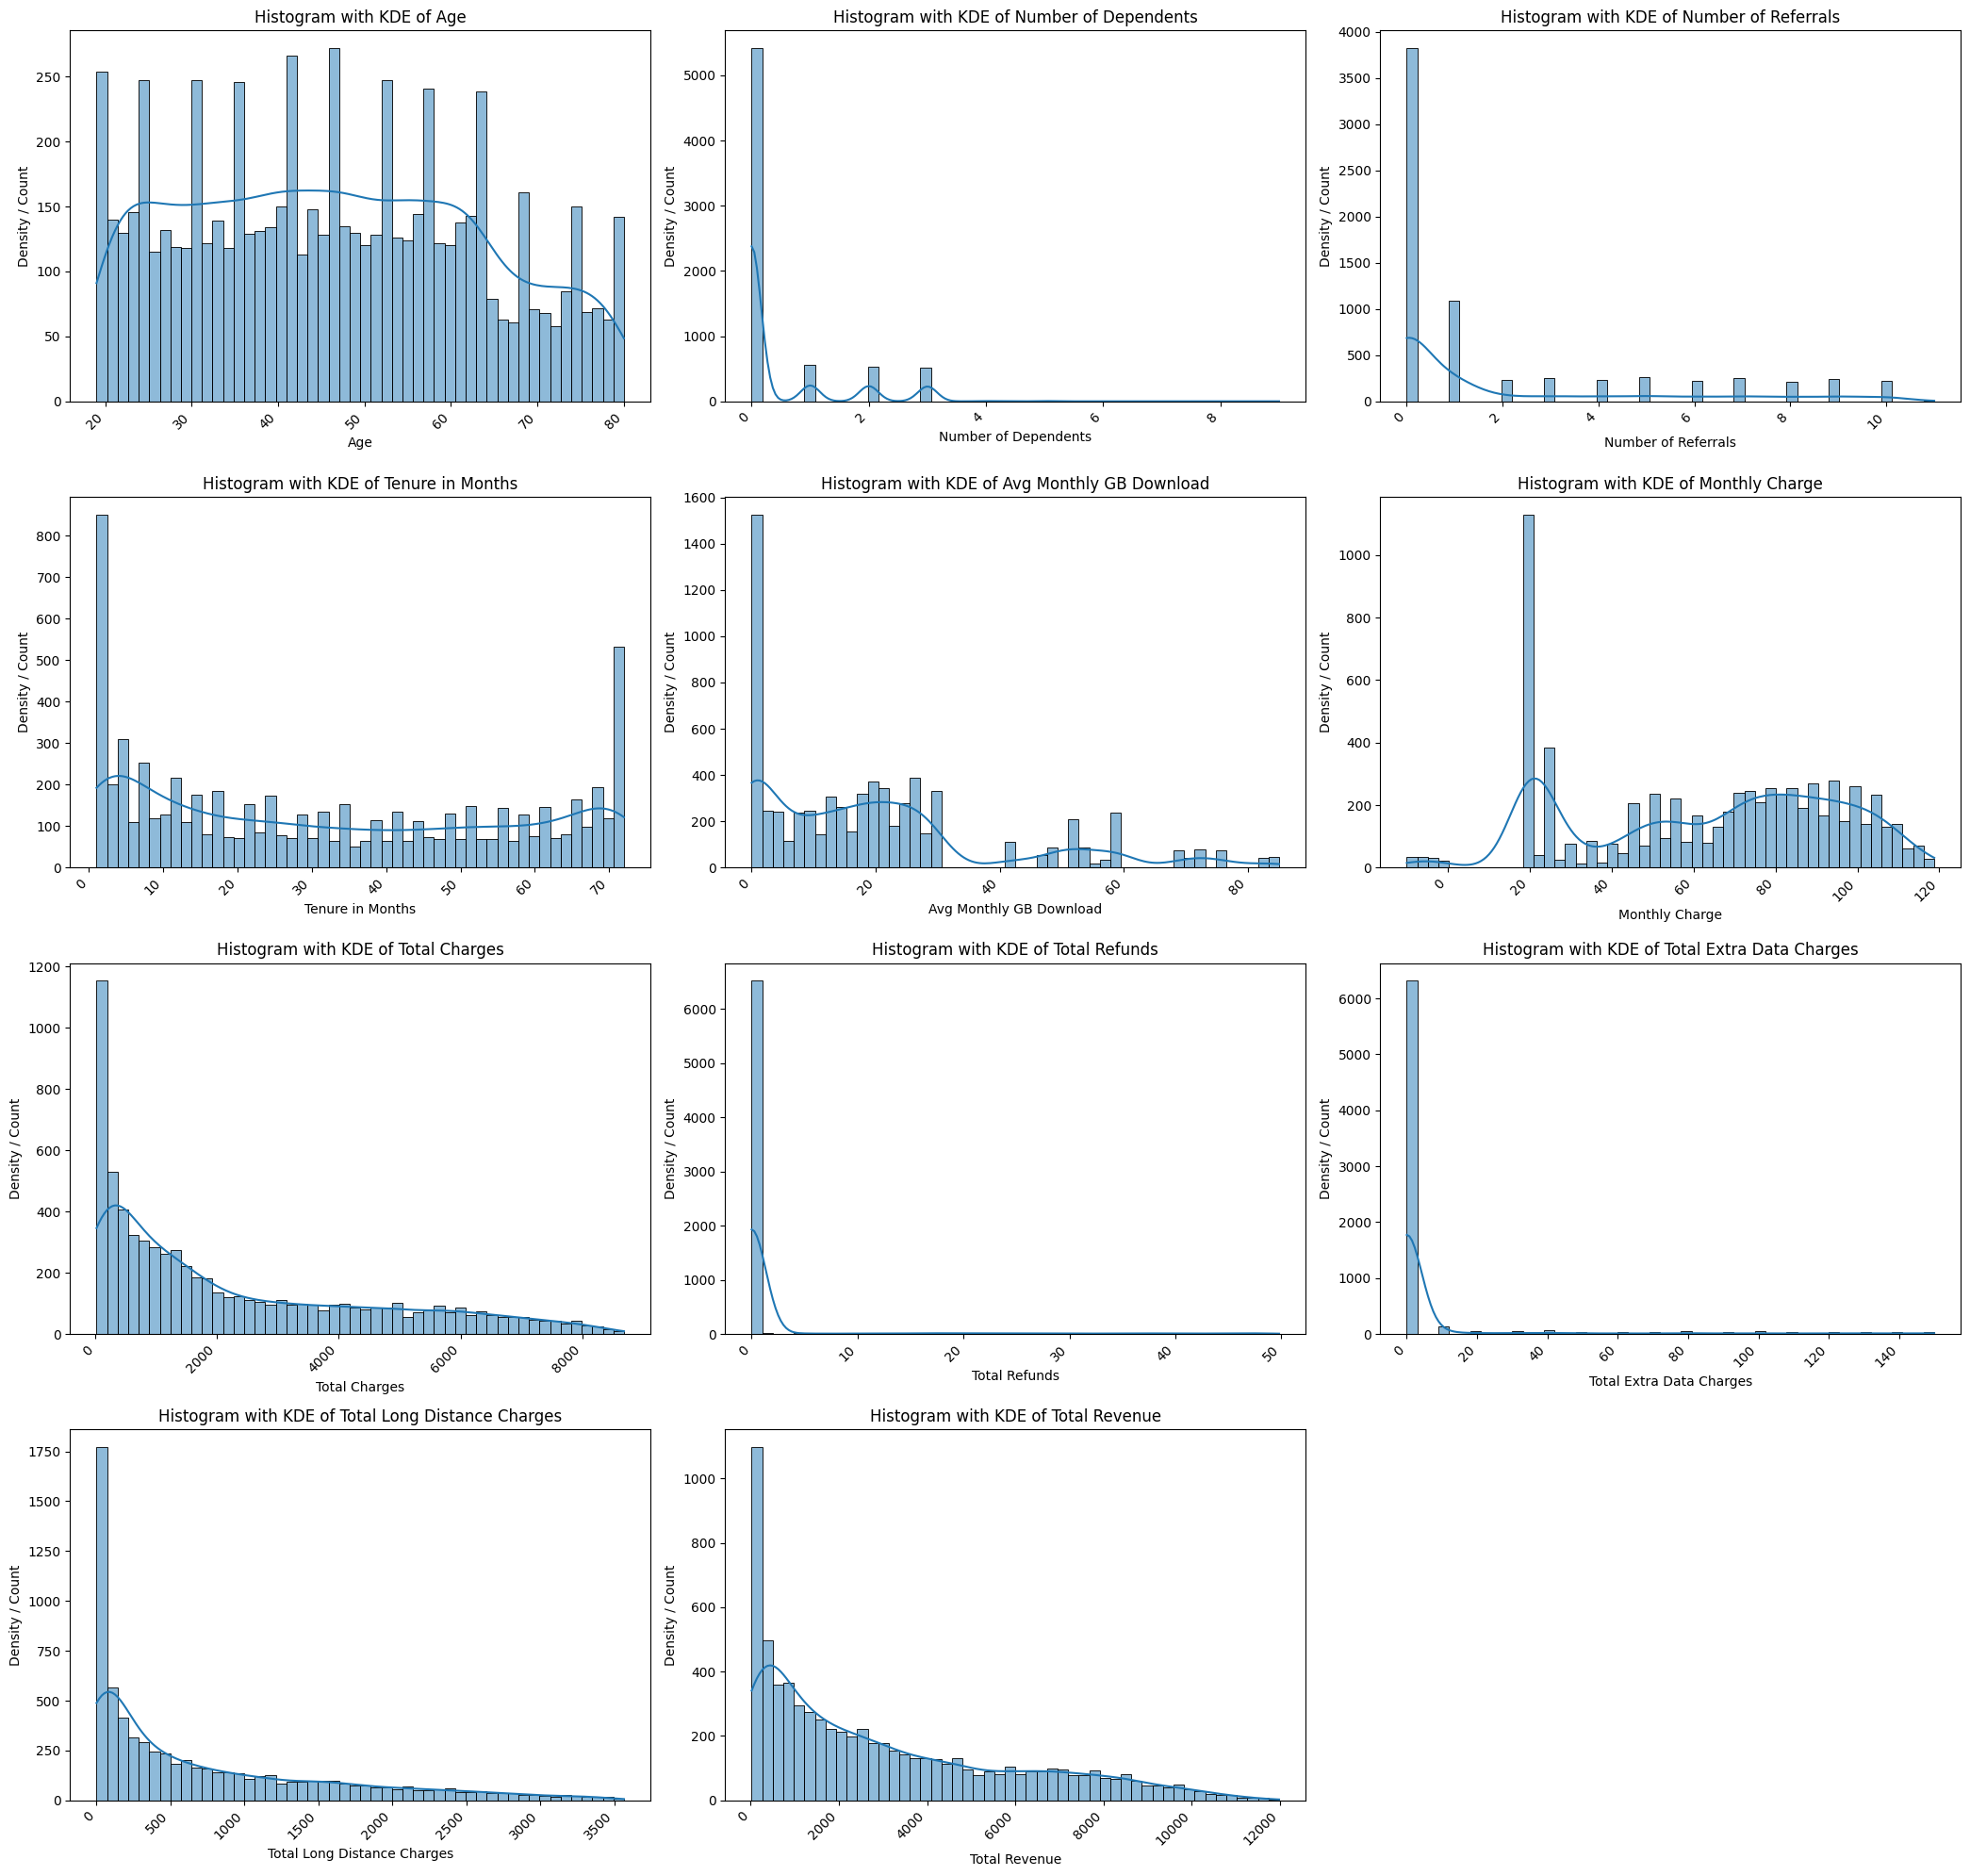

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

numerical_cols = dataset.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Calculate grid dimensions for subplots
num_features = len(numerical_cols)
num_cols_plot = 3 # Aim for 3 columns per row for better readability
num_rows_plot = math.ceil(num_features / num_cols_plot)

plt.figure(figsize=(num_cols_plot * 7, num_rows_plot * 5))

for i, column in enumerate(numerical_cols):
    plt.subplot(num_rows_plot, num_cols_plot, i + 1)
    sns.histplot(data=dataset, x=column, kde=True, bins=50, palette='viridis', legend=False)
    plt.title(f'Histogram with KDE of {column}')
    plt.xlabel(column)
    plt.ylabel('Density / Count')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [31]:
dataset['Total Refunds'].value_counts()

,count
Total Refunds,
0.00,6518
5.73,2
8.74,2
1.31,2
41.74,2
...,...
2.93,1
33.73,1
16.91,1


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


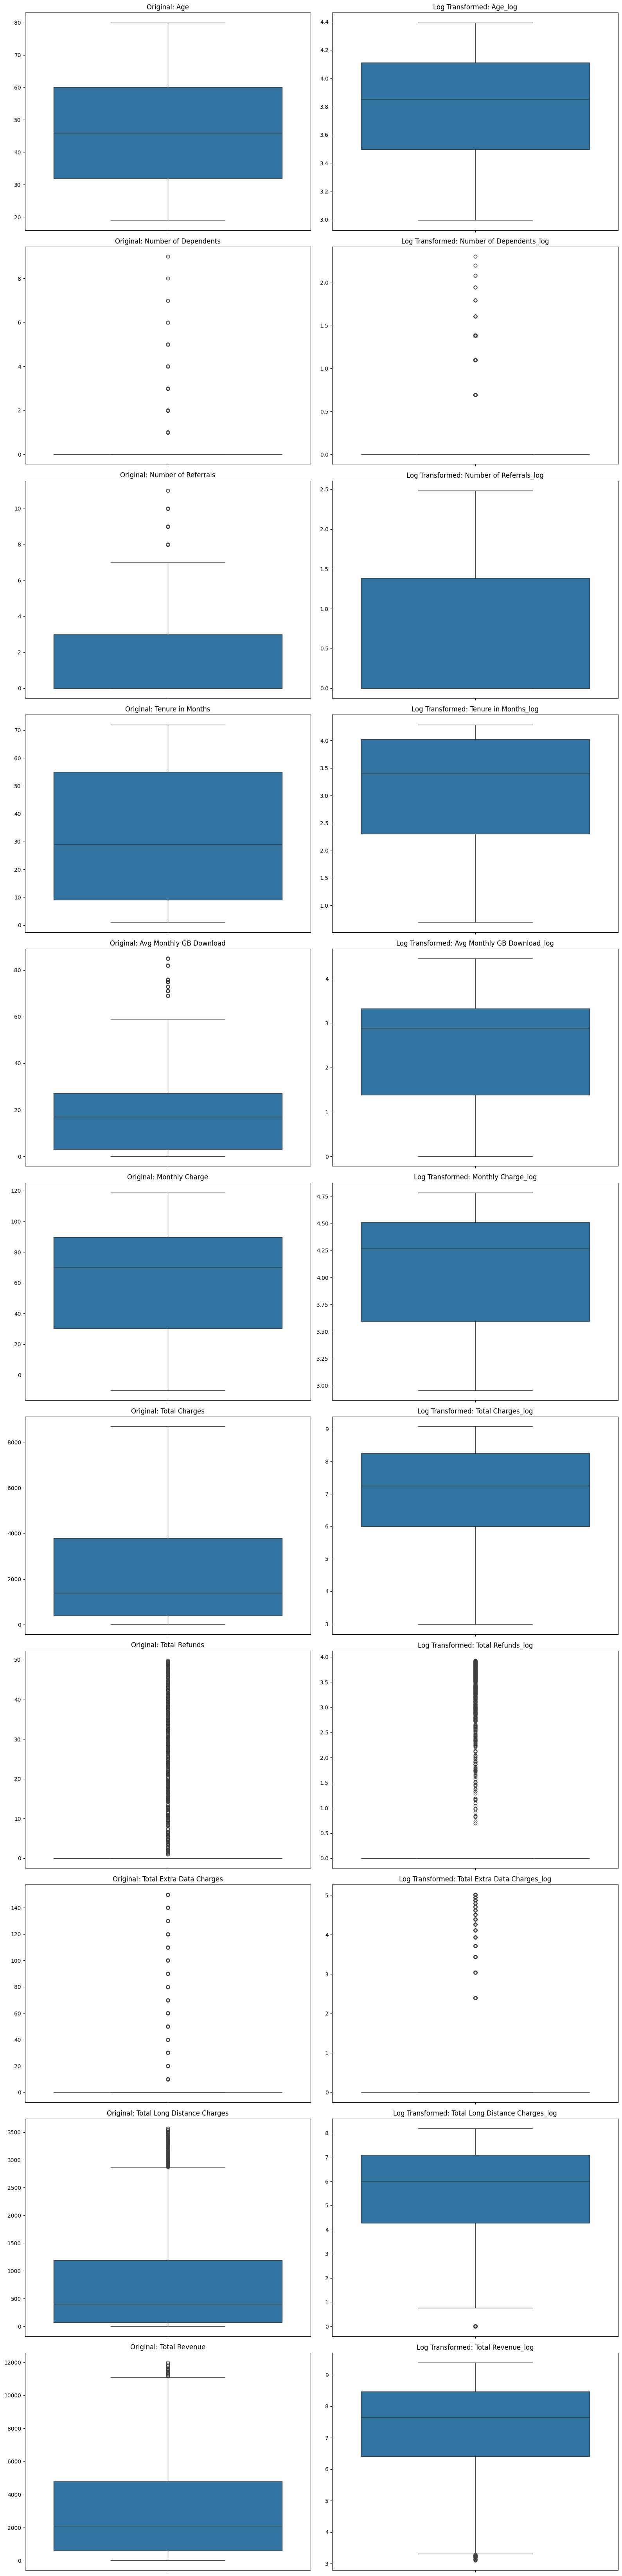

In [32]:



# Identify numerical columns that might benefit from log transformation due to skewness
numerical_col = dataset.select_dtypes(include = ['int64', 'float64']).columns


# Apply log transformation (np.log1p handles 0 values by computing log(1+x))
for col in numerical_col:
    dataset[col + '_log'] = np.log1p(dataset[col])

# Generate box plots for original and log-transformed columns
num_cols_plot = 2 # Original vs Transformed
num_rows_plot = len(numerical_col)

plt.figure(figsize=(num_cols_plot * 8, num_rows_plot * 6))

for i, col in enumerate(numerical_col):
    # Original column boxplot
    plt.subplot(num_rows_plot, num_cols_plot, i * num_cols_plot + 1)
    sns.boxplot(y=dataset[col])
    plt.title(f'Original: {col}')
    plt.ylabel('')

    # Log-transformed column boxplot
    plt.subplot(num_rows_plot, num_cols_plot, i * num_cols_plot + 2)
    sns.boxplot(y=dataset[col + '_log'])
    plt.title(f'Log Transformed: {col + '_log'}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

### 1. Count Plot with Hue: 'Online Security' vs 'Customer Status'

This plot will visually demonstrate how the presence or absence of 'Online Security' correlates with different 'Customer Status' categories (Stayed, Churned, Joined). It helps in understanding if 'Online Security' is a differentiating factor for customer status.

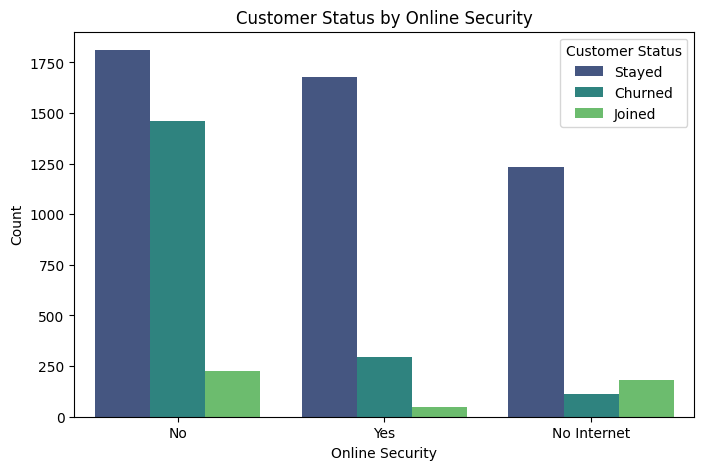

In [33]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Online Security', hue='Customer Status', data=dataset, palette='viridis')
plt.title('Customer Status by Online Security')
plt.xlabel('Online Security')
plt.ylabel('Count')
plt.legend(title='Customer Status')
plt.show()

### 2. Correlation Heatmap

This heatmap will display the Pearson correlation coefficients between all numerical and one-hot encoded boolean columns in your dataset. High correlation values (close to 1 or -1) indicate a strong linear relationship, which can help identify multicollinearity or important feature relationships. The `annot=True` parameter will show the correlation values on the heatmap.

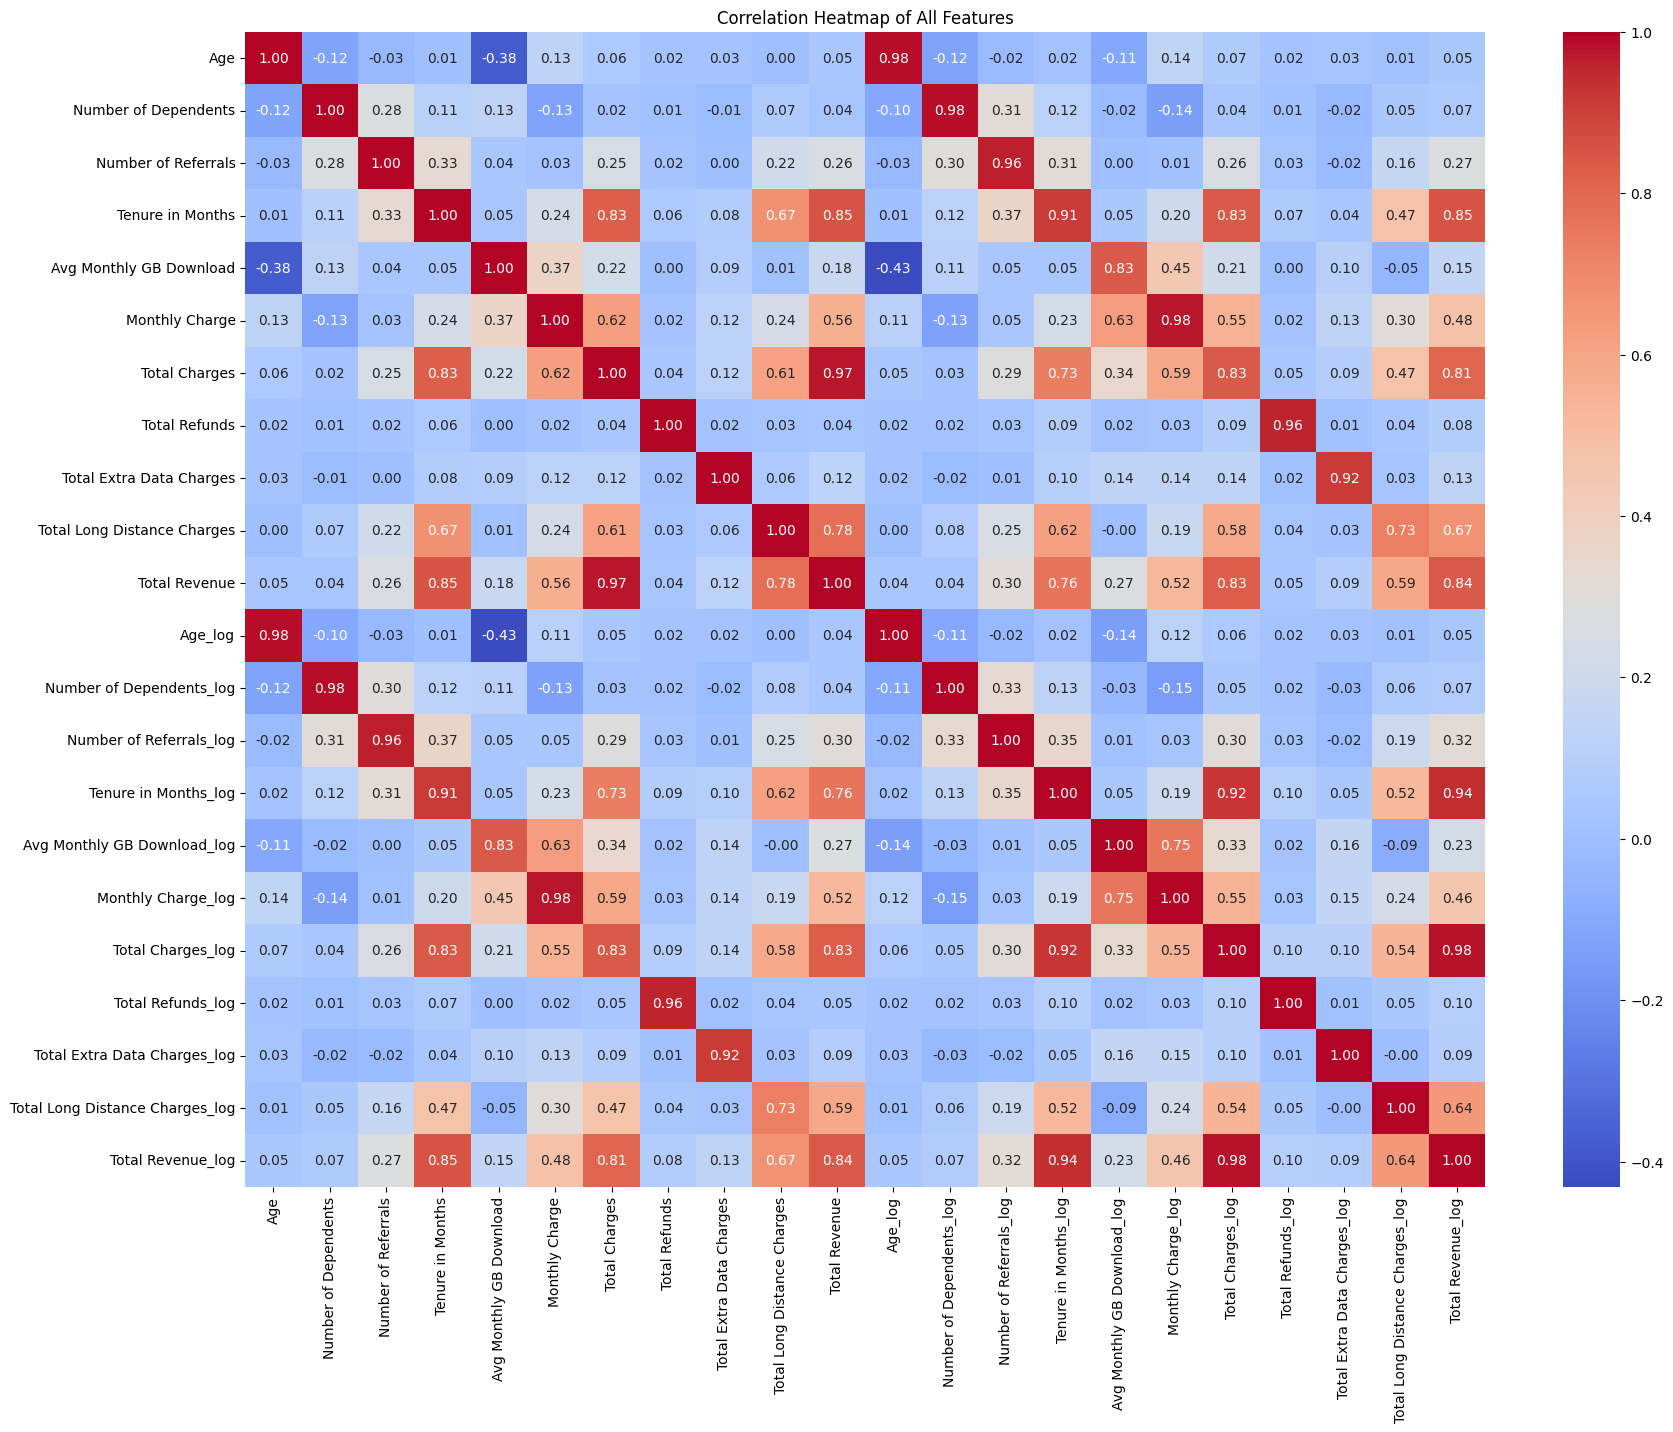

In [34]:
plt.figure(figsize=(20, 15))
sns.heatmap(dataset.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of All Features')
plt.show()

In [35]:
dataset.head()

,Age,Married,Number of Dependents,Number of Referrals,Tenure in Months,Offer,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,...,Number of Dependents_log,Number of Referrals_log,Tenure in Months_log,Avg Monthly GB Download_log,Monthly Charge_log,Total Charges_log,Total Refunds_log,Total Extra Data Charges_log,Total Long Distance Charges_log,Total Revenue_log
0,37,Yes,0,2,9,No Offer,No,Yes,Cable,16.0,...,0.0,1.098612,2.302585,2.833213,4.198705,6.387384,0.000000,0.000000,5.946755,6.883268
1,46,No,0,0,9,No Offer,Yes,Yes,Cable,10.0,...,0.0,0.000000,2.302585,2.397895,NaN,6.297846,3.671988,2.397895,4.576874,6.415555
2,50,No,0,0,4,Offer E,No,Yes,Fiber Optic,30.0,...,0.0,0.000000,1.609438,3.433987,4.316154,5.641375,0.000000,0.000000,4.909709,6.031766
3,78,Yes,0,1,13,Offer D,No,Yes,Fiber Optic,4.0,...,0.0,0.693147,2.639057,1.609438,4.595120,7.121939,0.000000,0.000000,5.893466,7.378078
4,75,Yes,0,3,3,No Offer,No,Yes,Fiber Optic,11.0,...,0.0,1.386294,1.386294,2.484907,4.441474,5.592478,0.000000,0.000000,3.141563,5.671741


In [36]:
dataset['Customer Status'].value_counts()

,count
Customer Status,
Stayed,4720
Churned,1869
Joined,454


In [37]:


# 9. Define y_multi_class as the 'Customer Status' column (multi-class target)
y_multi_class = dataset['Customer Status']

# 10. Create X_multi_class by dropping the 'Customer Status' column
X_multi_class = dataset.drop(columns=['Customer Status'])

# 11. Identify all remaining object type columns in X_multi_class and apply one-hot encoding
categorical_cols_for_ohe = X_multi_class.select_dtypes(include='object').columns.tolist()
X_multi_class = pd.get_dummies(X_multi_class, columns=categorical_cols_for_ohe, drop_first=True)

# 12. Convert any boolean columns in X_multi_class to integers (from one-hot encoding)
boolean_cols = X_multi_class.select_dtypes(include='bool').columns
X_multi_class[boolean_cols] = X_multi_class[boolean_cols].astype(int)

# 13. Handle any remaining NaNs/Infs that might have crept in (e.g., if a new transformation was applied incorrectly)
# This is a safeguard.
initial_rows_X = X_multi_class.shape[0]
X_multi_class = X_multi_class.replace([np.inf, -np.inf], np.nan).dropna()
dropped_rows_count = initial_rows_X - X_multi_class.shape[0]
if dropped_rows_count > 0:
    print(f"Dropped {dropped_rows_count} rows from X_multi_class due to NaNs/Infs during final cleaning.")

# 14. Align y_multi_class to match the index of the cleaned X_multi_class
y_multi_class = y_multi_class.loc[X_multi_class.index]

# Display prepared features and target
print("\n--- Prepared Features (X_multi_class) ---")
display(X_multi_class.head())
print("\n--- Prepared Target (y_multi_class) ---")
display(y_multi_class.head())
print("Unique classes in y_multi_class:", y_multi_class.unique())

Dropped 120 rows from X_multi_class due to NaNs/Infs during final cleaning.

--- Prepared Features (X_multi_class) ---


,Age,Number of Dependents,Number of Referrals,Tenure in Months,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,...,Premium Tech Support_Yes,Streaming TV_No Internet,Streaming TV_Yes,Unlimited Data_No Internet,Unlimited Data_Yes,Contract_One Year,Contract_Two Year,Paperless Billing_Yes,Payment Method_Credit Card,Payment Method_Mailed Check
0,37,0,2,9,16.0,65.6,593.30,0.0,0,381.51,...,1,0,1,0,1,1,0,1,1,0
2,50,0,0,4,30.0,73.9,280.85,0.0,0,134.60,...,0,0,0,0,1,0,0,1,0,0
3,78,0,1,13,4.0,98.0,1237.85,0.0,0,361.66,...,0,0,1,0,1,0,0,1,0,0
4,75,0,3,3,11.0,83.9,267.40,0.0,0,22.14,...,1,0,1,0,1,0,0,1,1,0
5,23,3,0,9,73.0,69.4,571.45,0.0,0,150.93,...,1,0,1,0,1,0,0,1,1,0



--- Prepared Target (y_multi_class) ---


,Customer Status
0,Stayed
2,Churned
3,Churned
4,Churned
5,Stayed


Unique classes in y_multi_class: ['Stayed' 'Churned' 'Joined']


After the features (`X_multi_class`) are prepared and the multi-class target (`y_multi_class`) is defined, the next step is to encode the `y_multi_class` into numerical labels for model training using `LabelEncoder`:

In [38]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform y_multi_class to get numerical labels
y_encoded = le.fit_transform(y_multi_class)

# Split data into training and testing sets with the encoded target
X_train_multi, X_test_multi, y_train_multi_encoded, y_test_multi_encoded = train_test_split(
    X_multi_class, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("--- Encoded Multi-class Target (y_train_multi_encoded) ---")
display(pd.Series(y_train_multi_encoded).head())
print("Original class labels (mapping from numerical to string):")
print(le.classes_)

--- Encoded Multi-class Target (y_train_multi_encoded) ---


,0
0,2
1,2
2,0
3,2
4,2


Original class labels (mapping from numerical to string):
['Churned' 'Joined' 'Stayed']


In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Initialize StandardScaler
scaler = StandardScaler()

# Define models and their pipelines
models_multi = [
    ('Logistic Regression', Pipeline(steps=[('scaler', scaler), ('model', LogisticRegression(random_state=42, solver='liblinear', multi_class='ovr'))])),
    ('Random Forest', Pipeline(steps=[('scaler', scaler), ('model', RandomForestClassifier(random_state=42))])),
    ('XGBoost', Pipeline(steps=[('scaler', scaler), ('model', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'))]))
]

# Lists to store accuracies and model names
model_names_multi = []
train_accuracies_multi = []
test_accuracies_multi = []

print("--- Multi-class Classification Model Training and Evaluation ---")
for name, pipeline in models_multi:
    # Train the model
    pipeline.fit(X_train_multi, y_train_multi_encoded)

    # Calculate training accuracy
    train_acc = pipeline.score(X_train_multi, y_train_multi_encoded)

    # Calculate testing accuracy
    test_acc = pipeline.score(X_test_multi, y_test_multi_encoded)

    # Store results
    model_names_multi.append(name)
    train_accuracies_multi.append(train_acc)
    test_accuracies_multi.append(test_acc)

    print(f"\nModel: {name}")
    print(f"  Training Accuracy: {train_acc:.4f}")
    print(f"  Testing Accuracy: {test_acc:.4f}")


--- Multi-class Classification Model Training and Evaluation ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



Model: Logistic Regression
  Training Accuracy: 0.8397
  Testing Accuracy: 0.8426

Model: Random Forest
  Training Accuracy: 1.0000
  Testing Accuracy: 0.8433


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:01:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model: XGBoost
  Training Accuracy: 0.9962
  Testing Accuracy: 0.8484


### Hyperparameter Tuning with GridSearchCV

Now, let's use `GridSearchCV` to find the optimal hyperparameters for the Random Forest and XGBoost models, which are more prone to overfitting. This will help us achieve a better balance between bias and variance.

In [40]:
from sklearn.model_selection import GridSearchCV

# --- Random Forest GridSearchCV ---
print("\n--- Running GridSearchCV for Random Forest ---")

# Define the parameter grid for Random Forest
param_grid_rf = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, 15],
    'model__min_samples_leaf': [2, 5, 10]
}

# Get the Random Forest pipeline (without specific hyperparameters yet)
rf_base_pipeline = Pipeline(steps=[('scaler', StandardScaler()), ('model', RandomForestClassifier(random_state=42))])

grid_search_rf = GridSearchCV(rf_base_pipeline, param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train_multi, y_train_multi_encoded)

print("Best parameters for Random Forest:", grid_search_rf.best_params_)
print("Best cross-validation accuracy for Random Forest:", grid_search_rf.best_score_)

# Get the best Random Forest model
best_rf_model = grid_search_rf.best_estimator_
rf_train_acc_tuned = best_rf_model.score(X_train_multi, y_train_multi_encoded)
rf_test_acc_tuned = best_rf_model.score(X_test_multi, y_test_multi_encoded)

print(f"Tuned Random Forest Training Accuracy: {rf_train_acc_tuned:.4f}")
print(f"Tuned Random Forest Testing Accuracy: {rf_test_acc_tuned:.4f}")

# --- XGBoost GridSearchCV ---
print("\n--- Running GridSearchCV for XGBoost ---")

# Define the parameter grid for XGBoost
param_grid_xgb = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__colsample_bytree': [0.6, 0.8, 1.0]
}

# Get the XGBoost pipeline (without specific hyperparameters yet)
xgb_base_pipeline = Pipeline(steps=[('scaler', StandardScaler()), ('model', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'))])

grid_search_xgb = GridSearchCV(xgb_base_pipeline, param_grid_xgb, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_xgb.fit(X_train_multi, y_train_multi_encoded)

print("Best parameters for XGBoost:", grid_search_xgb.best_params_)
print("Best cross-validation accuracy for XGBoost:", grid_search_xgb.best_score_)

# Get the best XGBoost model
best_xgb_model = grid_search_xgb.best_estimator_
xgb_train_acc_tuned = best_xgb_model.score(X_train_multi, y_train_multi_encoded)
xgb_test_acc_tuned = best_xgb_model.score(X_test_multi, y_test_multi_encoded)

print(f"Tuned XGBoost Training Accuracy: {xgb_train_acc_tuned:.4f}")
print(f"Tuned XGBoost Testing Accuracy: {xgb_test_acc_tuned:.4f}")



--- Running GridSearchCV for Random Forest ---
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters for Random Forest: {'model__max_depth': 15, 'model__min_samples_leaf': 2, 'model__n_estimators': 300}
Best cross-validation accuracy for Random Forest: 0.8275550740339472
Tuned Random Forest Training Accuracy: 0.9661
Tuned Random Forest Testing Accuracy: 0.8448

--- Running GridSearchCV for XGBoost ---
Fitting 3 folds for each of 81 candidates, totalling 243 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:07:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters for XGBoost: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__n_estimators': 300}
Best cross-validation accuracy for XGBoost: 0.8430841459010473
Tuned XGBoost Training Accuracy: 0.8651
Tuned XGBoost Testing Accuracy: 0.8635


### Evaluation Metrics for Multi-class Classification

Now, let's evaluate each model using a confusion matrix and ROC/AUC curves. For multi-class classification, ROC/AUC can be computed using a 'one-vs-rest' approach, where each class is treated as the positive class against all others.


--- Evaluating Logistic Regression ---


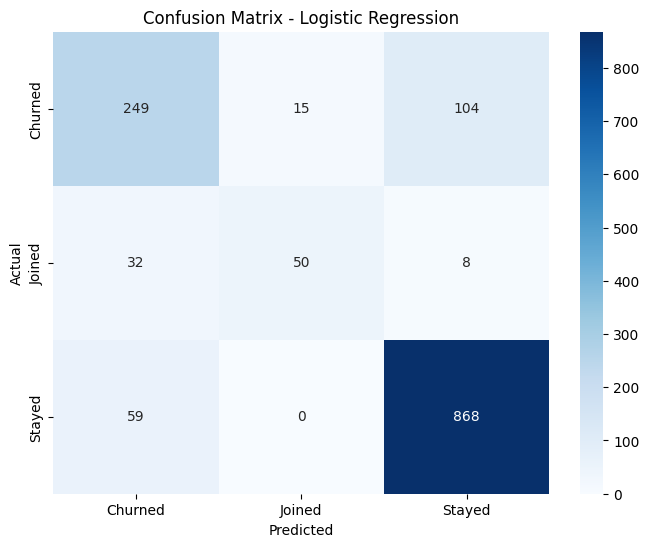

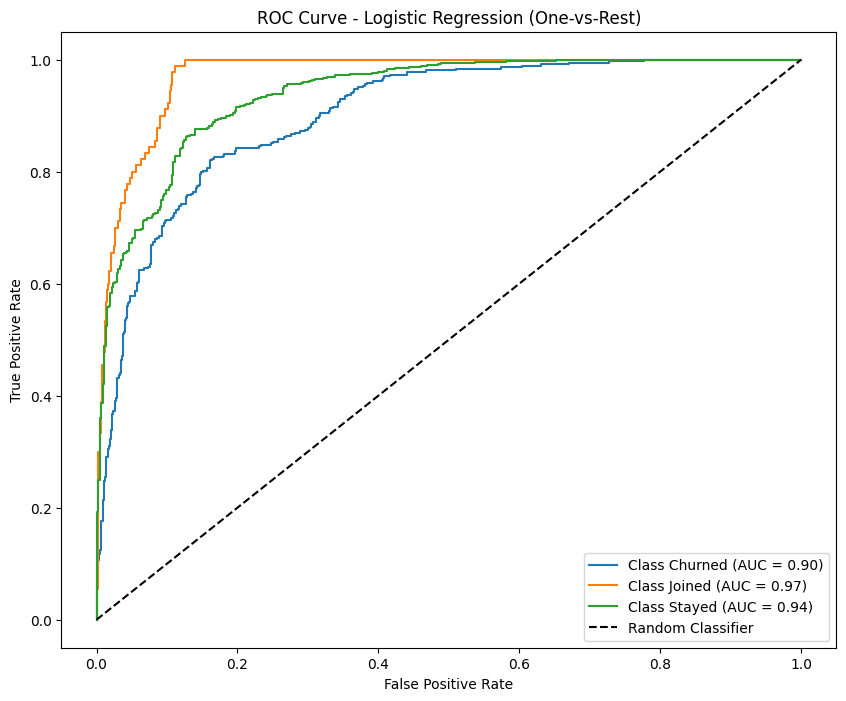

In [41]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize

# Get the best performing model (XGBoost in this case based on previous run)
best_model_index = test_accuracies_multi.index(max(test_accuracies_multi))
best_model_name = model_names_multi[best_model_index]

# --- Evaluation for Logistic Regression ---
print("\n--- Evaluating Logistic Regression ---")

# Get the Logistic Regression pipeline
logreg_pipeline = models_multi[0][1]
y_pred_logreg = logreg_pipeline.predict(X_test_multi)
y_proba_logreg = logreg_pipeline.predict_proba(X_test_multi)

# Confusion Matrix
plt.figure(figsize=(8, 6)) # Create a new figure for each plot
cm_logreg = confusion_matrix(y_test_multi_encoded, y_pred_logreg)
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve and AUC (One-vs-Rest)
n_classes = len(le.classes_)
y_test_binarized = label_binarize(y_test_multi_encoded, classes=range(n_classes))

plt.figure(figsize=(10, 8)) # Create a new figure for each plot
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_proba_logreg[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {le.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression (One-vs-Rest)')
plt.legend(loc='lower right')
plt.show()







--- Evaluating Random Forest ---


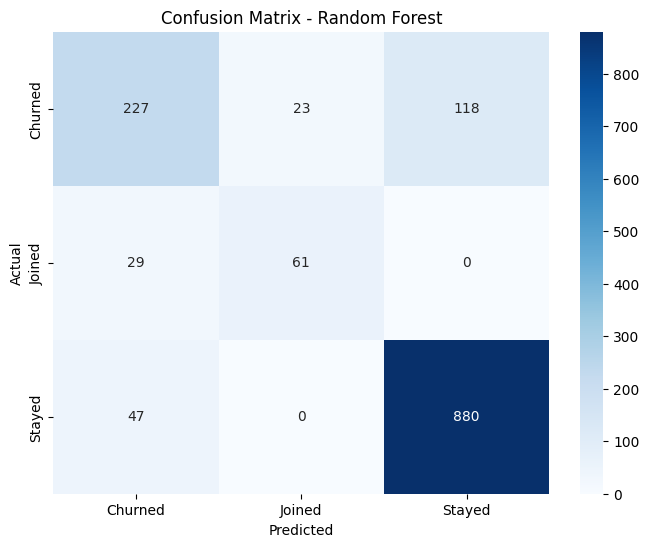

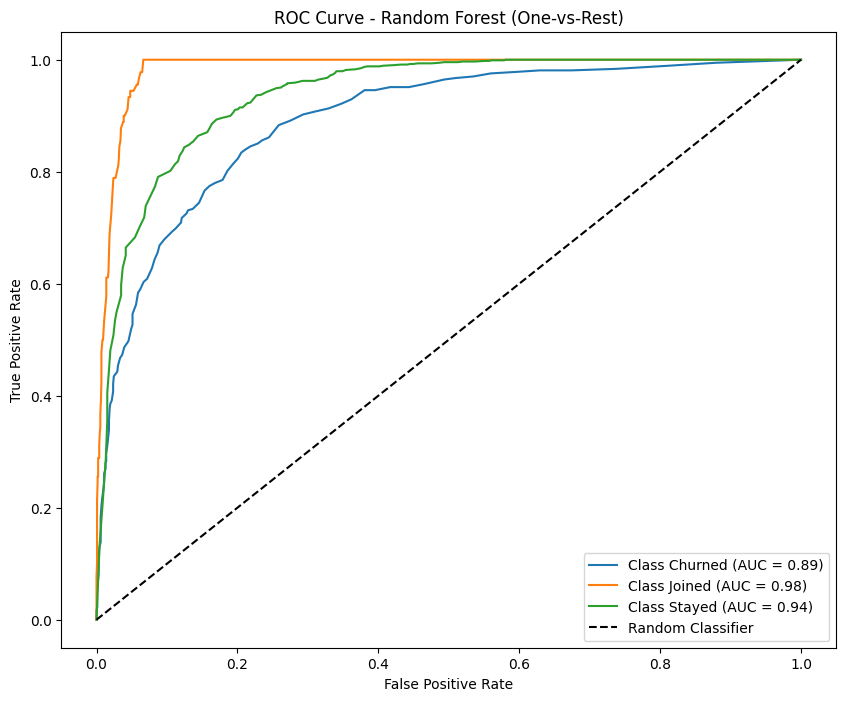

In [42]:
# --- Evaluation for Random Forest ---
print("\n--- Evaluating Random Forest ---")

# Get the Random Forest pipeline
rf_pipeline = models_multi[1][1]
y_pred_rf = rf_pipeline.predict(X_test_multi)
y_proba_rf = rf_pipeline.predict_proba(X_test_multi)

# Confusion Matrix
plt.figure(figsize=(8, 6)) # Create a new figure for each plot
cm_rf = confusion_matrix(y_test_multi_encoded, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve and AUC (One-vs-Rest)
plt.figure(figsize=(10, 8)) # Create a new figure for each plot
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_proba_rf[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {le.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest (One-vs-Rest)')
plt.legend(loc='lower right')
plt.show()


--- Evaluating XGBoost ---


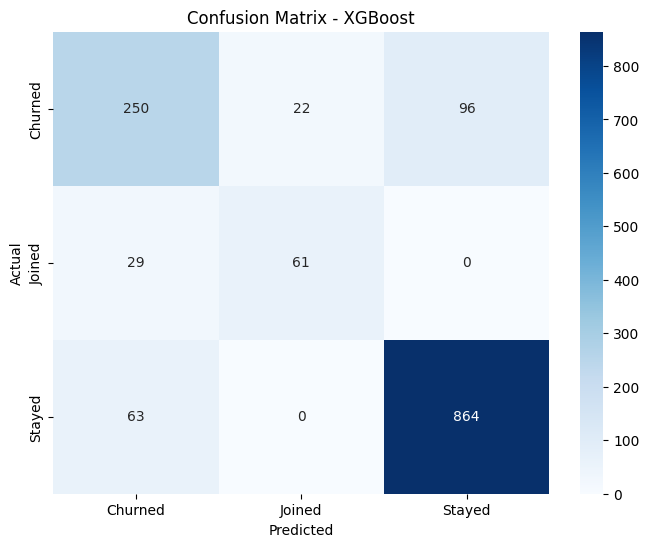

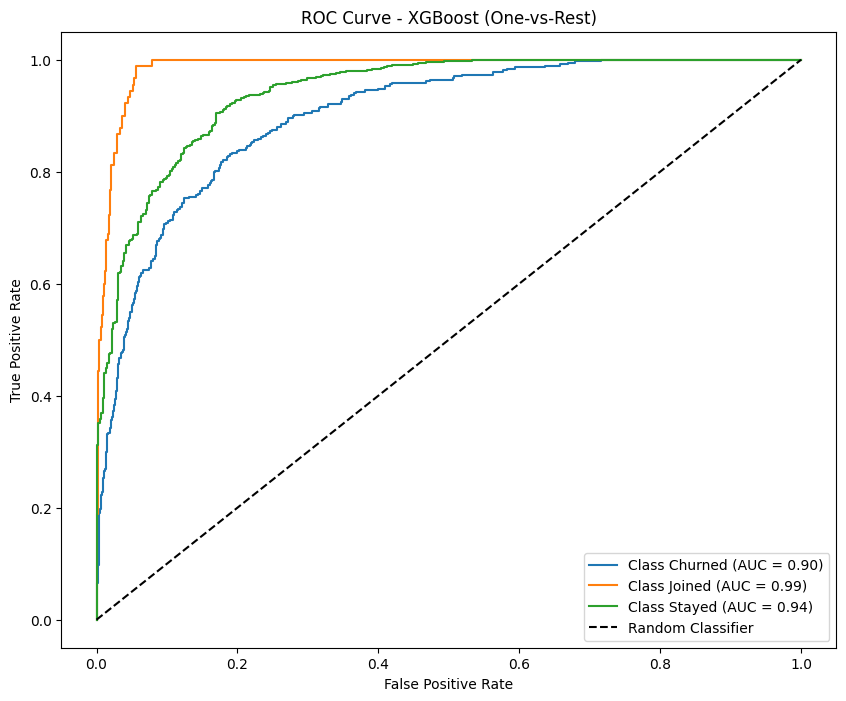

In [43]:

# --- Evaluation for XGBoost ---
print("\n--- Evaluating XGBoost ---")

# Get the XGBoost pipeline
xgb_pipeline = models_multi[2][1]
y_pred_xgb = xgb_pipeline.predict(X_test_multi)
y_proba_xgb = xgb_pipeline.predict_proba(X_test_multi)

# Confusion Matrix
plt.figure(figsize=(8, 6)) # Create a new figure for each plot
cm_xgb = confusion_matrix(y_test_multi_encoded, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve and AUC (One-vs-Rest)
plt.figure(figsize=(10, 8)) # Create a new figure for each plot
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_proba_xgb[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {le.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost (One-vs-Rest)')
plt.legend(loc='lower right')
plt.show()

In [45]:
import joblib

# Features ka list (same order jo tumne training me use kiya tha)
columns = X_multi_class.columns.tolist()
joblib.dump(columns, "columns.pkl")

['columns.pkl']

In [50]:
joblib.dump(best_xgb_model, "xgb.pkl")

['xgb.pkl']